In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
life_data = pd.read_csv('/content/Life Expectancy Data.csv')

In [111]:
life_data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [112]:
life_data.shape

(2938, 22)

In [113]:
life_data.dtypes

,0
Country,object
Year,int64
Status,object
Life expectancy,float64
Adult Mortality,float64
infant deaths,int64
Alcohol,float64
percentage expenditure,float64
Hepatitis B,float64
Measles,int64


In [114]:
life_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [115]:
life_data.isna().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


Checking missing values and identifying numerical columns

In [116]:
life_data.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [117]:
# numerical columns
num_cols = ['Year','Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling']

In [118]:
# categorical column - status and country
cat_cols = ['status','country']

# Handling Missing values

In [119]:
life_data.isna()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2934,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2935,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2936,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [120]:
life_data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2933,False
2934,False
2935,False
2936,False


Filling Missing values in Numerical columns using mean/median imputation

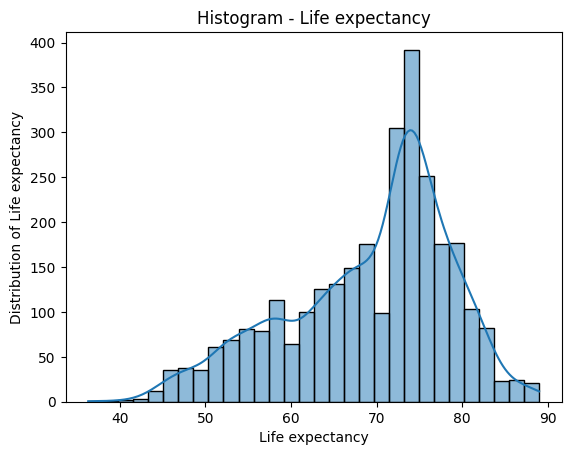

In [121]:
sns.histplot(life_data['Life expectancy '], kde=True)
plt.xlabel('Life expectancy')
plt.ylabel('Distribution of Life expectancy')
plt.title('Histogram - Life expectancy')
plt.show()

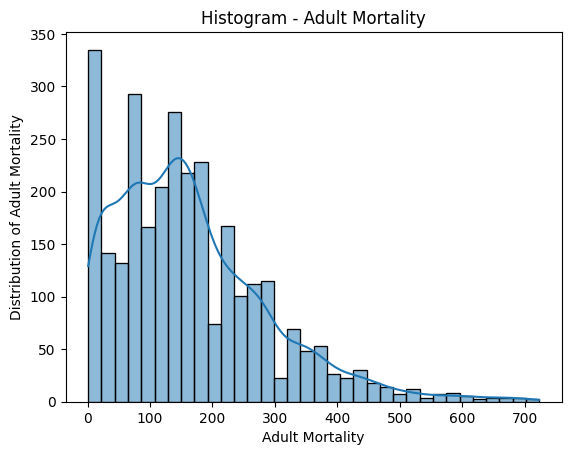

In [122]:
sns.histplot(life_data['Adult Mortality'],kde=True)
plt.xlabel('Adult Mortality')
plt.ylabel('Distribution of Adult Mortality')
plt.title('Histogram - Adult Mortality')
plt.show()

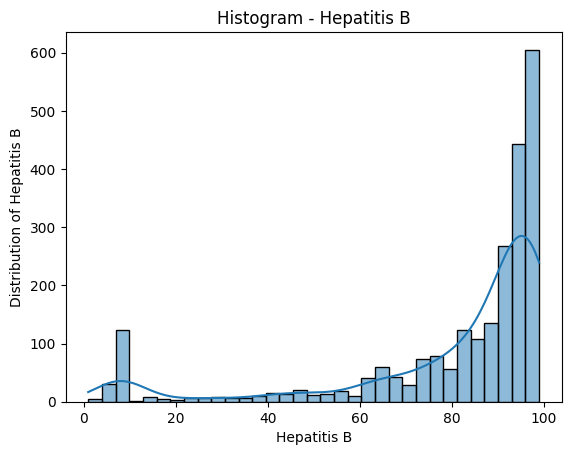

In [123]:
sns.histplot(life_data['Hepatitis B'],kde=True)
plt.xlabel('Hepatitis B')
plt.ylabel('Distribution of Hepatitis B')
plt.title('Histogram - Hepatitis B')
plt.show()

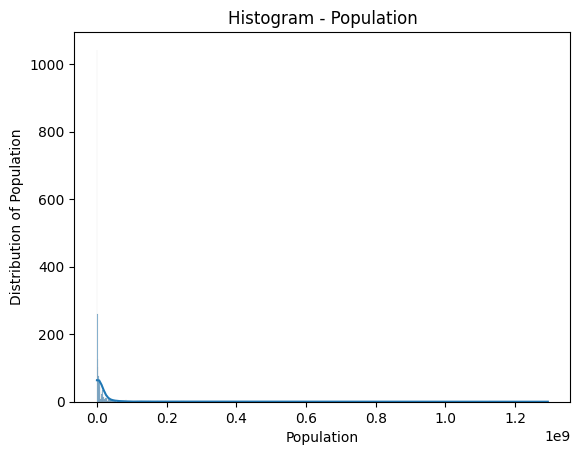

In [124]:
sns.histplot(life_data['Population'],kde=True)
plt.xlabel('Population')
plt.ylabel('Distribution of Population')
plt.title('Histogram - Population')
plt.show()

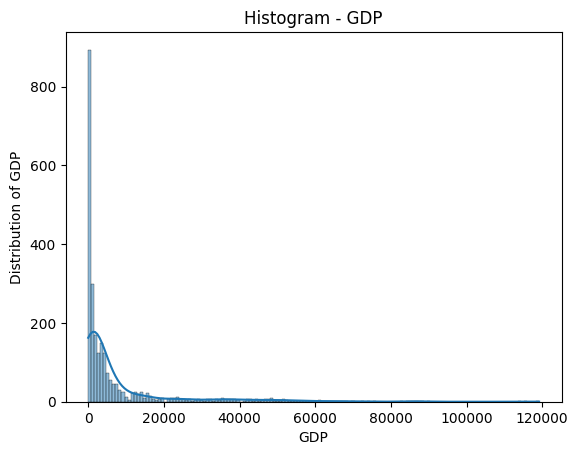

In [125]:
sns.histplot(life_data['GDP'],kde=True)
plt.xlabel('GDP')
plt.ylabel('Distribution of GDP')
plt.title('Histogram - GDP')
plt.show()

In [126]:
# filling missing values numerical columns with median
life_data['Adult Mortality'].median()


144.0

In [127]:
life_data['Adult Mortality'] = life_data['Adult Mortality'].fillna(life_data['Adult Mortality'].median())

In [128]:
life_data['Alcohol'].median()

3.755

In [129]:
life_data['Alcohol'] = life_data['Alcohol'].fillna(life_data['Alcohol'].median())


In [130]:
life_data['Hepatitis B'].median()

92.0

In [131]:
life_data['Hepatitis B'] = life_data['Hepatitis B'].fillna(life_data['Hepatitis B'].median())


In [132]:
life_data[' BMI '].median()

43.5

In [133]:
life_data[' BMI '] = life_data[' BMI '].fillna(life_data[' BMI '].median())


In [134]:
life_data['Polio'].median()

93.0

In [135]:
life_data['Polio'] = life_data['Polio'].fillna(life_data['Polio'].median())

In [136]:
life_data['Total expenditure'].median()

5.755

In [137]:
life_data['Total expenditure'] = life_data['Total expenditure'].fillna(life_data['Total expenditure'].median())

In [138]:
life_data['Diphtheria '].median()

93.0

In [139]:
life_data['Diphtheria '] = life_data['Diphtheria '].fillna(life_data['Diphtheria '].median())

In [140]:
life_data['GDP'].median()

1766.947595

In [141]:
life_data['GDP'] = life_data['GDP'].fillna(life_data['GDP'].median())

In [142]:
life_data['Population'].median()

1386542.0

In [143]:
life_data['Population'] = life_data['Population'].fillna(life_data['Population'].median())

thinness 1-19 years	34
thinness 5-9 years	34
Income composition of resources	167
Schooling	163


In [144]:
life_data[' thinness  1-19 years'].median()

3.3

In [145]:
life_data[' thinness  1-19 years'] = life_data[' thinness  1-19 years'].fillna(life_data[' thinness  1-19 years'].median())

In [146]:
life_data[' thinness 5-9 years'].median()

3.3

In [147]:
life_data[' thinness 5-9 years'] = life_data[' thinness 5-9 years'].fillna(life_data[' thinness 5-9 years'].median())

In [148]:
life_data['Income composition of resources'].median()

0.677

In [149]:
life_data['Income composition of resources'] = life_data['Income composition of resources'].fillna(life_data['Income composition of resources'].median())

In [150]:
life_data['Schooling'].median()

12.3

In [151]:
life_data['Schooling'] = life_data['Schooling'].fillna(life_data['Schooling'].median())

In [152]:
# target column - Life expectancy, dropping the missing values

In [153]:
life_data = life_data.dropna(subset=['Life expectancy '])

In [154]:
life_data.isna().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,0
Adult Mortality,0
infant deaths,0
Alcohol,0
percentage expenditure,0
Hepatitis B,0
Measles,0


Drop unwanted column - country

In [155]:
life_data = life_data.drop('Country', axis=1)

In [156]:
life_data

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


# Outliers

In [157]:
# Handling outliers using IQR method

num_cols = life_data.select_dtypes(include='number').columns

print(num_cols)

Index(['Year', 'Life expectancy ', 'Adult Mortality', 'infant deaths',
       'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ',
       'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ',
       ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years',
       ' thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')


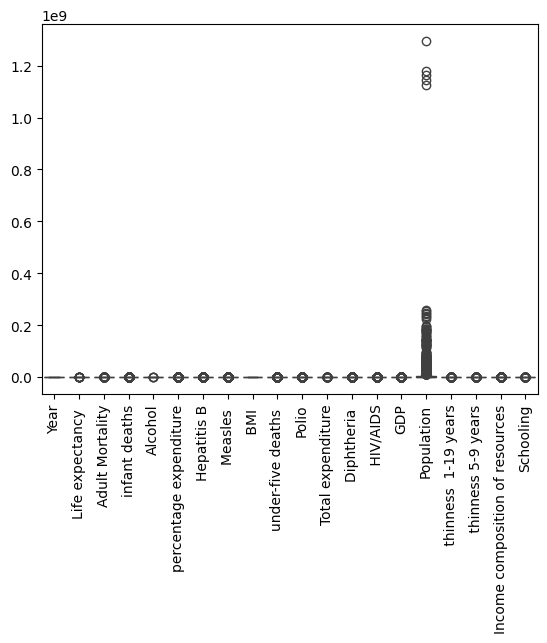

In [158]:
sns.boxplot(life_data)
plt.xticks(rotation = 90)
plt.show()

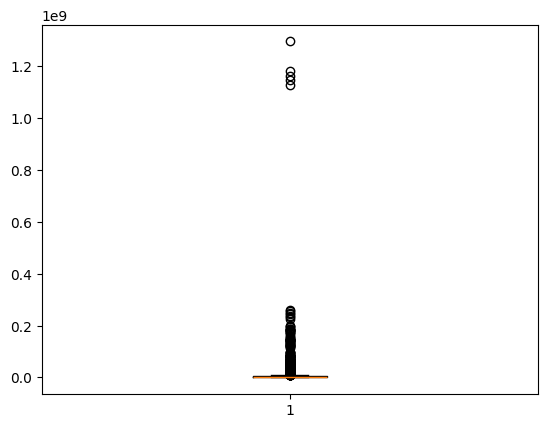

In [159]:
plt.boxplot(life_data['Population'])
plt.show()

In [160]:
life_data.columns

Index(['Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

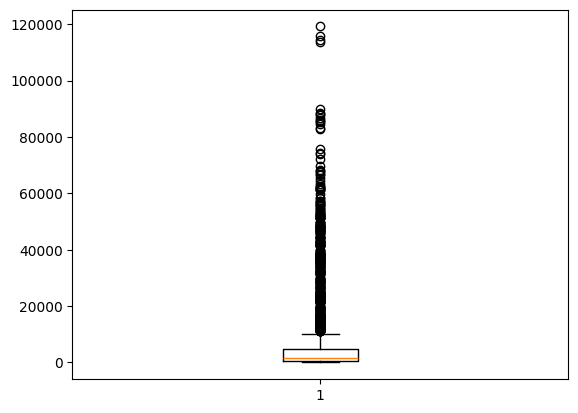

In [161]:
plt.boxplot(life_data['GDP'])
plt.show()

In [162]:
for col in num_cols:
    Q1 = life_data[col].quantile(0.25)
    Q3 = life_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((life_data[col] < lower) | (life_data[col] > upper)).sum()

    print(col, ":", outliers)

Year : 0
Life expectancy  : 10
Adult Mortality : 82
infant deaths : 315
Alcohol : 3
percentage expenditure : 388
Hepatitis B : 320
Measles  : 542
 BMI  : 0
under-five deaths  : 394
Polio : 278
Total expenditure : 49
Diphtheria  : 297
 HIV/AIDS : 542
GDP : 445
Population : 452
 thinness  1-19 years : 100
 thinness 5-9 years : 99
Income composition of resources : 130
Schooling : 75


In [163]:
# Taking the numerical columns excluding the target column
num_cols = life_data.drop('Life expectancy ', axis=1).select_dtypes(include='number').columns

# IQR method + Capping
for col in num_cols:
    Q1 = life_data[col].quantile(0.25)
    Q3 = life_data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    life_data[col] = life_data[col].clip(lower=lower, upper=upper)

# Encoding

In [164]:
# one hot encoding for status column
life_data = pd.get_dummies(life_data, columns=['Status'], dtype=int)

In [165]:
life_data.head()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,...,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Status_Developed,Status_Developing
0,2015,65.0,263.0,55,0.01,71.279624,65.0,905.625,19.1,70,...,65.0,0.1,584.259210,1.085476e+07,15.35,15.6,0.479,10.1,0,1
1,2014,59.9,271.0,55,0.01,73.523582,62.0,492.000,18.6,70,...,62.0,0.1,612.696514,3.275820e+05,15.35,15.6,0.476,10.0,0,1
2,2013,59.9,268.0,55,0.01,73.219243,64.0,430.000,18.1,70,...,64.0,0.1,631.744976,1.085476e+07,15.35,15.6,0.470,9.9,0,1
3,2012,59.5,272.0,55,0.01,78.184215,67.0,905.625,17.6,70,...,67.0,0.1,669.959000,3.696958e+06,15.35,15.6,0.463,9.8,0,1
4,2011,59.2,275.0,55,0.01,7.097109,68.0,905.625,17.2,70,...,68.0,0.1,63.537231,2.978599e+06,15.35,15.6,0.454,9.5,0,1


# Seperating feature and target columns

In [166]:
x = life_data.drop('Life expectancy ', axis=1)
y = life_data['Life expectancy ']

In [167]:
 # Before that splitting dependent feature(target column) and independent features
 y = life_data['Life expectancy '].reset_index(drop=True) # target variable
 x = life_data.drop('Life expectancy ',axis = 1) # feature variable

# Train test split

In [168]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size = 0.2,random_state = 42
)

In [169]:
x

,Year,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,...,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Status_Developed,Status_Developing
0,2015,263.0,55,0.01,71.279624,65.0,905.625,19.1,70,49.5,...,65.0,0.10,584.259210,1.085476e+07,15.35,15.6,0.479,10.1,0,1
1,2014,271.0,55,0.01,73.523582,62.0,492.000,18.6,70,58.0,...,62.0,0.10,612.696514,3.275820e+05,15.35,15.6,0.476,10.0,0,1
2,2013,268.0,55,0.01,73.219243,64.0,430.000,18.1,70,62.0,...,64.0,0.10,631.744976,1.085476e+07,15.35,15.6,0.470,9.9,0,1
3,2012,272.0,55,0.01,78.184215,67.0,905.625,17.6,70,67.0,...,67.0,0.10,669.959000,3.696958e+06,15.35,15.6,0.463,9.8,0,1
4,2011,275.0,55,0.01,7.097109,68.0,905.625,17.2,70,68.0,...,68.0,0.10,63.537231,2.978599e+06,15.35,15.6,0.454,9.5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,459.0,27,4.36,0.000000,68.0,31.000,27.1,42,67.0,...,65.0,1.85,454.366654,1.085476e+07,9.40,9.4,0.407,9.2,0,1
2934,2003,459.0,26,4.06,0.000000,61.0,905.625,26.7,41,49.5,...,68.0,1.85,453.351155,1.085476e+07,9.80,9.9,0.418,9.5,0,1
2935,2002,73.0,25,4.43,0.000000,73.0,304.000,26.3,40,73.0,...,71.0,1.85,57.348340,1.255250e+05,1.20,1.3,0.427,10.0,0,1
2936,2001,459.0,25,1.72,0.000000,76.0,529.000,25.9,39,76.0,...,75.0,1.85,548.587312,1.085476e+07,1.60,1.7,0.427,9.8,0,1


In [170]:
y

,Life expectancy
0,65.0
1,59.9
2,59.9
3,59.5
4,59.2
...,...
2923,44.3
2924,44.5
2925,44.8
2926,45.3


# Scaling

In [171]:
x1 = x.copy()

In [172]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [173]:
# scaled x_train1 and x_test1
from sklearn.model_selection import train_test_split
x_train1, x_test1, y_train, y_test = train_test_split(x1, y, test_size=0.2, random_state=42)

In [174]:
# non scaled x_train and x_test

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Linear Regression

In [175]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [176]:
# Linear regression with scaled data
lr_model_scaled = LinearRegression()
lr_model_scaled.fit(x_train1, y_train)
y_pred_lr_model_scaled = lr_model_scaled.predict(x_test1)

# Regression evaluation metrics
print('R2 Score is: ', r2_score(y_test, y_pred_lr_model_scaled))
print('MAE is: ', mean_absolute_error(y_test, y_pred_lr_model_scaled))
print('RMSE is: ', mean_squared_error(y_test, y_pred_lr_model_scaled) ** 0.5)

R2 Score is:  0.8550045664290228
MAE is:  2.6997313161574215
RMSE is:  3.5414712117152383


# Decision Tree

In [177]:
from sklearn.tree import DecisionTreeRegressor

In [178]:
# Create Linear Regression model
lr_model_scaled = LinearRegression()

# Train the model using scaled training data
lr_model_scaled.fit(x_train1, y_train)

# Make predictions using scaled test data
y_pred_lr_model_scaled = lr_model_scaled.predict(x_test1)

print('R2 Score is: ', r2_score(y_test, y_pred_lr_model_scaled))
print('MAE is: ', mean_absolute_error(y_test, y_pred_lr_model_scaled))
print('RMSE is: ', mean_squared_error(y_test, y_pred_lr_model_scaled) ** 0.5)

R2 Score is:  0.8550045664290228
MAE is:  2.6997313161574215
RMSE is:  3.5414712117152383




# Random Forest



In [179]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regression
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train1, y_train)

y_pred_rf_model = rf_model.predict(x_test1)

# Regression evaluation metrics
print('R2 Score is: ', r2_score(y_test, y_pred_rf_model))
print('MAE is: ', mean_absolute_error(y_test, y_pred_rf_model))
print('RMSE is: ', mean_squared_error(y_test, y_pred_rf_model) ** 0.5)

R2 Score is:  0.9670928123581555
MAE is:  1.0523805460750872
RMSE is:  1.687143166165791


Random Forest Regression performed best because it achieved the highest R2 score and the lowest MAE and RMSE among the models tested. It is able to capture complex and non-linear relationships in the Life Expectancy dataset.